In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
path_to_test = r"data\customer_clv_test.csv"
path_to_train = r"data\customer_clv_train.csv"
path_to_transactions = r"data\transactions_2016_2017.csv"

In [4]:
train = pd.read_csv(path_to_train)
test = pd.read_csv(path_to_test)
transactions = pd.read_csv(path_to_transactions)

print("Dimensions: train:", train.shape, " test:", test.shape, 'transactions:', transactions.shape)
print("Train columns:", train.columns.to_list())
print("Transaction columns:", transactions.columns.to_list())

C:\Users\Marte\AppData\Local\Temp\ipykernel_23016\3911849424.py:3: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(path_to_transactions)


Dimensions: train: (116591, 2)  test: (29148, 1) transactions: (344212, 26)
Train columns: ['cust_id', 'revenue_2018_2019']
Transaction columns: ['cust_id', 'order_date', 'pack_date', 'sale_id', 'sale_discount_applied', 'sale_revenue', 'returned_to_shop_id', 'prod_id', 'prod_size', 'prod_web_only', 'prod_season', 'prod_brand', 'prod_title', 'prod_color', 'prod_type_1', 'prod_type_3', 'prod_type_4', 'prod_type_5', 'prod_heel', 'prod_material', 'prod_insole', 'prod_print', 'prod_comfort_sole', 'prod_comfort_wear', 'prod_clasp', 'prod_outlet']


In [5]:
train.head()

,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


In [6]:
transactions.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,NaN,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,NaN,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,high-top sneakers,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,NaN,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,NaN,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0


In [7]:
transactions["order_date"] = pd.to_datetime(transactions["order_date"], errors='coerce')
transactions['pack_date'] = pd.to_datetime(transactions["pack_date"], errors='coerce')

print("missing values in order_date:", transactions["order_date"].isna().sum())
print("missing values in pack_date:", transactions['pack_date'].isna().sum())

missing values in order_date: 0
missing values in pack_date: 0


rows : 116591 | percent of O: 63.41
count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
50%           0.000000
90%         229.940000
95%         363.465000
99%         704.242000
max        1197.940000
Name: revenue_2018_2019, dtype: float64


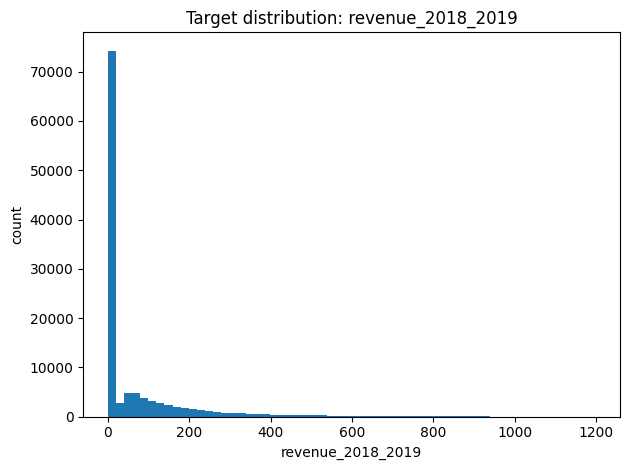

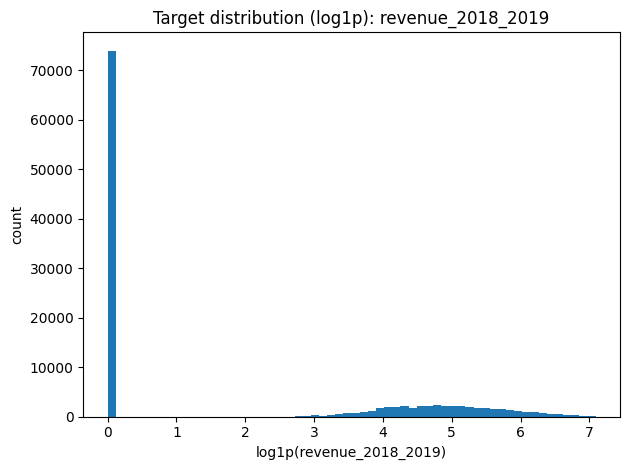

In [8]:
TARGET_VAR = "revenue_2018_2019"

y = pd.to_numeric(train[TARGET_VAR].dropna())
print('rows :', len(y), "| percent of O:", round(y.eq(0).mean() * 100,2))
print(y.describe(percentiles=[.5,.9,.95,.99]))

plt.figure()
plt.hist(y, bins=60)
plt.title(f"Target distribution: {TARGET_VAR}")
plt.xlabel(TARGET_VAR); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure()
plt.hist(np.log1p(y), bins=60)
plt.title(f"Target distribution (log1p): {TARGET_VAR}")
plt.xlabel(f"log1p({TARGET_VAR})"); plt.ylabel("count")
plt.tight_layout(); plt.show()



In [9]:
print(np.log1p(y).describe(percentiles=[.5,.9,.95,.99]))

count    116591.000000
mean          1.793202
std           2.416395
min           0.000000
50%           0.000000
90%           5.442158
95%           5.898431
99%           6.558541
max           7.089193
Name: revenue_2018_2019, dtype: float64


In [10]:
print(len(transactions['prod_brand'].unique()))

493


In [11]:
for column in transactions.columns.tolist():
    print("Missing values in", column, 'is', transactions[column].isna().sum(), " and percentage of the column missing", round(transactions[column].isna().mean() * 100, 2))

Missing values in cust_id is 0  and percentage of the column missing 0.0
Missing values in order_date is 0  and percentage of the column missing 0.0
Missing values in pack_date is 0  and percentage of the column missing 0.0
Missing values in sale_id is 0  and percentage of the column missing 0.0
Missing values in sale_discount_applied is 0  and percentage of the column missing 0.0
Missing values in sale_revenue is 0  and percentage of the column missing 0.0
Missing values in returned_to_shop_id is 280282  and percentage of the column missing 81.43
Missing values in prod_id is 0  and percentage of the column missing 0.0
Missing values in prod_size is 0  and percentage of the column missing 0.0
Missing values in prod_web_only is 0  and percentage of the column missing 0.0
Missing values in prod_season is 0  and percentage of the column missing 0.0
Missing values in prod_brand is 0  and percentage of the column missing 0.0
Missing values in prod_title is 0  and percentage of the column mi

In [12]:
for column in transactions.columns.to_list():
    print('Descriptive statistics for', column, ':', transactions[column].describe())

Descriptive statistics for cust_id : count               344212
unique              145739
top       yvmh4jb3ltqygxnt
freq                   142
Name: cust_id, dtype: object
Descriptive statistics for order_date : count                        344212
mean     2017-01-21 04:59:20.884571
min             2016-01-01 00:00:00
25%             2016-07-26 00:00:00
50%             2017-01-30 00:00:00
75%             2017-07-14 06:00:00
max             2017-12-31 00:00:00
Name: order_date, dtype: object
Descriptive statistics for pack_date : count                        344212
mean     2017-01-22 20:23:55.682661
min             2016-01-03 00:00:00
25%             2016-07-27 00:00:00
50%             2017-02-02 00:00:00
75%             2017-07-17 00:00:00
max             2018-01-12 00:00:00
Name: pack_date, dtype: object
Descriptive statistics for sale_id : count               344212
unique              245928
top       lwvlicnwtljqoq7z
freq                    28
Name: sale_id, dtype: object
Descri